In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import urllib3
import os
import re
import random
import warnings

warnings.filterwarnings("ignore")
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

for d in ["../data", "../results/figures", "../results/tables", "../models"]:
    os.makedirs(d, exist_ok=True)

RANDOM_SEED = 42
STANDARD_AA = set("ACDEFGHIKLMNPQRSTVWY")
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [8]:
def parse_fasta(text):
    """FASTA  → list of (header, sequence) tuples."""
    records, header, seq = [], None, []
    for line in text.splitlines():
        line = line.strip()
        if line.startswith(">"):
            if header is not None:
                records.append((header, "".join(seq)))
            header, seq = line[1:], []
        elif line:
            seq.append(line.upper())
    if header is not None:
        records.append((header, "".join(seq)))
    return records

def clean_seqs(records, min_len=10, max_len=100):
    """Keep only sequences with standard AAs and 10–100 residues; deduplicate."""
    seen, out = set(), []
    for _, seq in records:
        seq = re.sub(r'[^ACDEFGHIKLMNPQRSTVWY]', '', seq.upper())
        if min_len <= len(seq) <= max_len and seq not in seen:
            seen.add(seq)
            out.append(seq)
    return out

def fetch_uniprot(query, n=5000, timeout=60):
    url    = "https://rest.uniprot.org/uniprotkb/search"
    params = {"query": query, "format": "fasta", "size": 500}
    all_records, cursor = [], None
    while len(all_records) < n:
        if cursor:
            params["cursor"] = cursor
        r = requests.get(url, params=params, timeout=timeout, verify=False)
        r.raise_for_status()
        batch = parse_fasta(r.text)
        if not batch:
            break
        all_records.extend(batch)
        m = re.search(r'cursor=([^&>\s]+)', r.headers.get("Link", ""))
        cursor = m.group(1) if m else None
        if not cursor:
            break
    return all_records[:n]

def length_match(pos_seqs, neg_pool, bin_width=5, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    pos_lens = np.array([len(s) for s in pos_seqs])
    pool_lens = np.array([len(s) for s in neg_pool])
    bins = np.arange(0, pos_lens.max() + bin_width + 1, bin_width)
    counts = np.histogram(pos_lens, bins=bins)[0]
    sampled = []
    for cnt, lo, hi in zip(counts, bins[:-1], bins[1:]):
        if cnt == 0:
            continue
        idx = np.where((pool_lens >= lo) & (pool_lens < hi))[0]
        if len(idx) == 0:
            continue
        chosen = rng.choice(idx, size=min(cnt, len(idx)), replace=False)
        sampled.extend(neg_pool[i] for i in chosen)
    return sampled


In [ ]:
amp_query = "reviewed:true AND keyword:KW-0929 AND (length:[10 TO 100])"
amp_recs = fetch_uniprot(amp_query, n=5000)
fb_amp_seqs = clean_seqs(amp_recs)
print(f"AMPs: {len(fb_amp_seqs)}")

  AMPs: 2518


In [ ]:
print("Fetching non-AMPs from UniProt ...")
neg_query = "reviewed:true AND NOT keyword:KW-0929 AND (length:[10 TO 100])"
neg_recs = fetch_uniprot(neg_query, n=max(len(fb_amp_seqs) * 3, 3000))
amp_set = set(fb_amp_seqs)
fb_nonamp = [s for s in clean_seqs(neg_recs) if s not in amp_set]
print(f"non-AMPs: {len(fb_nonamp)}")

Fetching non-AMPs from UniProt ...
  non-AMPs: 6793


In [9]:
fb_nonamp_matched = length_match(fb_amp_seqs, fb_nonamp)

rows = ([{"sequence": s, "label": 1} for s in fb_amp_seqs] +
        [{"sequence": s, "label": 0} for s in fb_nonamp_matched])
df = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
df["seq_len"] = df["sequence"].apply(len)
df
# df.to_csv("../data/sequences.csv", index=False)

,sequence,label,seq_len
0,MKNYSKNATHLITVLLFSFVVILLIIPSKCEAVSNDMQPLEARSAD...,1,77
1,MKKVLFLVVALASFAFGADGEQIKAFSVVAAGIGLGVAALGGAIGM...,0,100
2,MASGSGPGAAASANLNAVRETMDVLLEISRILNTGLDMETLSICVR...,0,78
3,LECNKLVPIAHKTCPEGKNLCYKMFMVSTSTVPVKRGCIDVCPKDS...,0,60
4,MVKRKANHVINGMNDAKSQGKGAGYIENDQLVLTEAERQNNKKRKTNQ,0,48
...,...,...,...
4913,MANSNNKTNAQQVRKQNQQSASGQGQFGTEFASETNVQQVRKQNQQ...,0,82
4914,MNYLILISFALLVITGVESARDAYIAKPHNCVYECFDAFSSYCNGV...,1,86
4915,GVIPCGESCVFIPCISAAIGCSCKNKVCYRN,0,31
4916,MAQDLSEKELLRMEVEQLKKEVKNPRDLISKTGKEIKDYVEAQAGT...,0,69


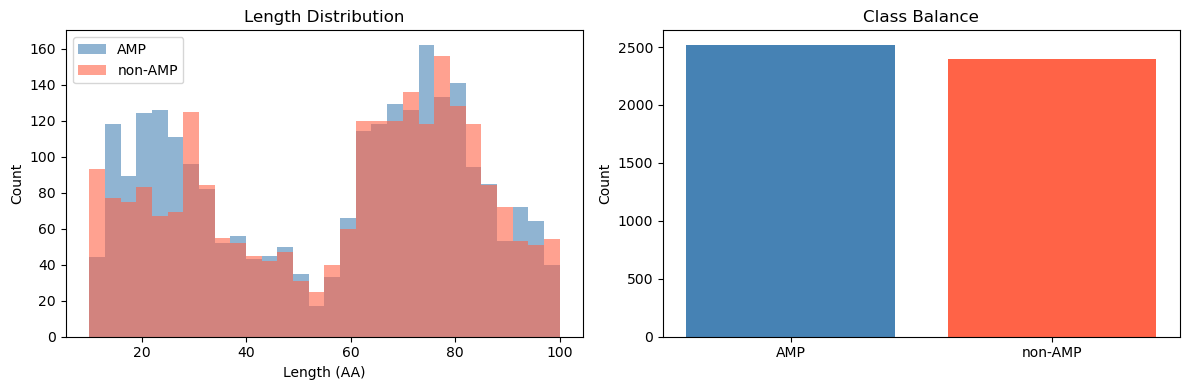

Total: 4918  |  AMPs: 2518  |  non-AMPs: 2400


In [11]:
df = pd.read_csv("../data/sequences.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, name, c in [(1,"AMP","steelblue"),(0,"non-AMP","tomato")]:
    axes[0].hist(df[df["label"]==label]["seq_len"], bins=30,
                 alpha=0.6, label=name, color=c)
axes[0].set_xlabel("Length (AA)"); axes[0].set_ylabel("Count")
axes[0].set_title("Length Distribution"); axes[0].legend()
axes[1].bar(["AMP","non-AMP"],
            [df["label"].sum(), (df["label"]==0).sum()],
            color=["steelblue","tomato"])
axes[1].set_ylabel("Count"); axes[1].set_title("Class Balance")
plt.tight_layout()
plt.savefig("../results/figures/00_dataset_final.png", dpi=150)
plt.show()
print(f"Total: {len(df)}  |  AMPs: {df['label'].sum()}  |  non-AMPs: {(df['label']==0).sum()}")